# Multilabel Toxic Comment Classification — v2

**Author:** Madhavan T
**Data:** [Jigsaw Toxic Comment Classification Challenge](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge) — ~160K Wikipedia talk-page comments, 6 non-exclusive labels:
`toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`.

### What changed from v1 (2022)
| v1 | v2 |
|---|---|
| Six separate binary datasets, each **down-sampled** (first N rows) | **One true multilabel model** trained on the full dataset |
| Evaluated on **balanced** test splits → optimistic F1 | Evaluated on the **official Kaggle test set** with its real class mix |
| F1 only | **ROC-AUC** (competition metric) + PR-AUC + F1 at tuned thresholds |
| Word TF-IDF only | Word **and character** n-gram TF-IDF (robust to misspellings / obfuscation like `f*ck`) |
| Fixed 0.5 threshold | **Per-label thresholds** tuned on a validation split |
| Saved model bug (`knn` pickled instead of the Random Forest) | One reproducible sklearn `Pipeline` saved with `joblib` |
| — | Error analysis, explainability (top n-grams), **identity-term bias check** |
| — | Optional DistilBERT fine-tune for comparison |

## 1. Setup

Works in **VS Code / Jupyter** (local) and **Google Colab**.
Local: `pip install -r requirements.txt` once, then pick that environment as the notebook kernel.

In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q iterative-stratification

In [2]:
import os, re, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, precision_recall_curve)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

## 2. Load data
Needs `train.csv`, `test.csv` and `test_labels.csv` from the Kaggle competition.

- **Local (VS Code):** run `python scripts/download_data.py` once (uses your Kaggle API key), or copy the three CSVs into `data/`.
- **Colab:** keep the CSVs in a Google Drive folder and set `COLAB_DATA_DIR`.

You must have accepted the competition rules on Kaggle for the API download to work.

In [3]:
COLAB_DATA_DIR = "/content/drive/MyDrive/Datasets from Kaggle (toxic)"   # used only in Colab

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = COLAB_DATA_DIR
else:
    DATA_DIR = "data"

needed = ["train.csv", "test.csv", "test_labels.csv"]
missing = [f for f in needed if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(f"Missing {missing} in '{DATA_DIR}'. Run: python scripts/download_data.py")

In [4]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
test_labels = pd.read_csv(os.path.join(DATA_DIR, "test_labels.csv"))

# Kaggle marks test rows that were NOT used for scoring with -1 -> drop them
test = test.merge(test_labels, on="id")
test = test[(test[LABELS] != -1).all(axis=1)].reset_index(drop=True)

print(f"train: {train.shape}   scored test: {test.shape}")
train.head()

train: (159571, 8)   scored test: (63978, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## 3. Exploratory data analysis

In [5]:
dist = pd.DataFrame({
    "train %": train[LABELS].mean() * 100,
    "test %":  test[LABELS].mean() * 100,
    "train count": train[LABELS].sum(),
}).round(2)
clean_share = (train[LABELS].sum(axis=1) == 0).mean() * 100
print(f"Clean comments (no label): {clean_share:.1f}%  -> heavy class imbalance")
dist

Clean comments (no label): 89.8%  -> heavy class imbalance


,train %,test %,train count
toxic,9.58,9.52,15294
severe_toxic,1.00,0.57,1595
obscene,5.29,5.77,8449
threat,0.30,0.33,478
insult,4.94,5.36,7877
identity_hate,0.88,1.11,1405


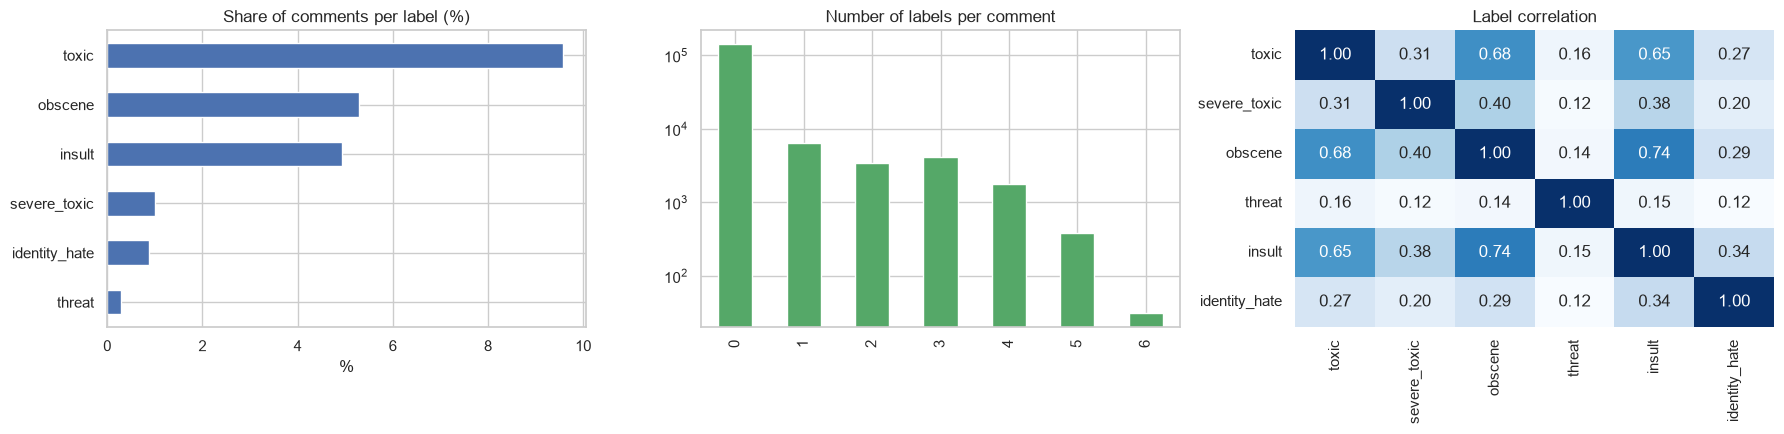

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

dist["train %"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Share of comments per label (%)"); axes[0].set_xlabel("%")

n_labels = train[LABELS].sum(axis=1).value_counts().sort_index()
n_labels.plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Number of labels per comment"); axes[1].set_yscale("log")

corr = train[LABELS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=axes[2], cbar=False)
axes[2].set_title("Label correlation")
plt.tight_layout(); plt.show()

**Takeaways**
- ~90% of comments are clean, and `threat` is only ~0.3% — accuracy or balanced-sample F1 would be misleading, so we use **ROC-AUC / PR-AUC** on the real distribution.
- Labels co-occur strongly (`obscene`↔`insult`↔`toxic`), which is why a single multilabel setup is more natural than six unrelated datasets.

In [7]:
train["n_chars"] = train.comment_text.str.len()
train["is_toxic_any"] = train[LABELS].max(axis=1)
train.groupby("is_toxic_any")["n_chars"].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
is_toxic_any,,,,,,,,
0,143346.0,404.0,587.0,6.0,102.0,216.0,452.0,5000.0
1,16225.0,303.0,619.0,8.0,61.0,128.0,283.0,5000.0


## 4. Text cleaning
Kept deliberately light: TF-IDF handles case and tokenisation, and character n-grams benefit from keeping
symbols like `*` and `!` (people write `f*ck`, `id!ot`). We only remove noise that carries no signal.

`clean_text` lives in `toxic_clean.py`, not in this notebook, for two reasons: the saved pipeline needs to
pickle its cleaning step *by reference* so the artifact cleans its own input, and the browser demo mirrors
this one definition in JS. Change it there and the JS has to follow (see `CLAUDE.md`).

In [8]:
# Single source of truth for cleaning, mirrored by cleanText() in web/index.html.
try:
    from toxic_clean import clean_text, TextCleaner
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "toxic_clean.py not found - run this notebook from the repo root "
        "(in Colab, clone the repo first so the module sits next to the notebook)."
    ) from e

train["text"] = train.comment_text.map(clean_text)
test["text"]  = test.comment_text.map(clean_text)
train.text.iloc[0]

"explanation why the edits made under my username hardcore metallica fan were reverted? they weren't vandalisms, just closure on some gas after i voted at new york dolls fac. and please don't remove the template from the talk page since i'm retired now. ip"

## 5. Train / validation split
Multilabel **iterative stratification** keeps rare labels (`threat`, `identity_hate`) represented in both splits.
Validation is used for model selection and threshold tuning; the official test set is touched only once, at the end.

In [9]:
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
tr_idx, va_idx = next(msss.split(train.text, train[LABELS].values))
X_tr_txt, X_va_txt = train.text.iloc[tr_idx], train.text.iloc[va_idx]
y_tr, y_va = train[LABELS].values[tr_idx], train[LABELS].values[va_idx]
X_te_txt, y_te = test.text, test[LABELS].values
print(len(X_tr_txt), len(X_va_txt), len(X_te_txt))

143613 15958 63978


## 6. Features: word + character TF-IDF

In [10]:
word_vec = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=2, max_features=100_000,
                           sublinear_tf=True, strip_accents="unicode", token_pattern=r"(?u)\b\w+\b")
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, max_features=100_000,
                           sublinear_tf=True, strip_accents="unicode")

t0 = time.time()
Xw_tr = word_vec.fit_transform(X_tr_txt); Xw_va = word_vec.transform(X_va_txt); Xw_te = word_vec.transform(X_te_txt)
Xc_tr = char_vec.fit_transform(X_tr_txt); Xc_va = char_vec.transform(X_va_txt); Xc_te = char_vec.transform(X_te_txt)
X_tr, X_va, X_te = hstack([Xw_tr, Xc_tr]).tocsr(), hstack([Xw_va, Xc_va]).tocsr(), hstack([Xw_te, Xc_te]).tocsr()
print(f"word feats {Xw_tr.shape[1]:,} | char feats {Xc_tr.shape[1]:,} | {time.time()-t0:.0f}s")

word feats 100,000 | char feats 100,000 | 340s


## 7. Model comparison (validation set)
All models are trained **once** on the full, imbalanced training data in a one-vs-rest multilabel setup.
`MultinomialNB` on word TF-IDF reproduces the spirit of the v1 baseline.

In [11]:
def scores(y_true, y_score):
    auc = [roc_auc_score(y_true[:, i], y_score[:, i]) for i in range(len(LABELS))]
    ap  = [average_precision_score(y_true[:, i], y_score[:, i]) for i in range(len(LABELS))]
    return np.array(auc), np.array(ap)

def get_scores(model, X):
    return model.predict_proba(X) if hasattr(model, "predict_proba") else model.decision_function(X)

candidates = {
    "MultinomialNB (word)":        (OneVsRestClassifier(MultinomialNB(alpha=0.1)), "word"),
    "LogReg (word)":               (OneVsRestClassifier(LogisticRegression(C=4, solver="liblinear", max_iter=1000)), "word"),
    "LinearSVC (word+char)":       (OneVsRestClassifier(LinearSVC(C=0.1)), "both"),
    "LogReg (word+char)":          (OneVsRestClassifier(LogisticRegression(C=4, solver="liblinear", max_iter=1000)), "both"),
}
feats = {"word": (Xw_tr, Xw_va), "both": (X_tr, X_va)}

rows, fitted = [], {}
for name, (model, f) in candidates.items():
    t0 = time.time()
    Xa, Xb = feats[f]
    model.fit(Xa, y_tr)
    auc, ap = scores(y_va, get_scores(model, Xb))
    fitted[name] = model
    rows.append({"model": name, "mean ROC-AUC": auc.mean(), "mean PR-AUC": ap.mean(),
                 **{f"AUC {l}": a for l, a in zip(LABELS, auc)}, "fit s": time.time() - t0})
    print(f"{name:<24} AUC={auc.mean():.4f}  PR-AUC={ap.mean():.4f}")

comparison = pd.DataFrame(rows).set_index("model").sort_values("mean ROC-AUC", ascending=False)
comparison.round(4)

MultinomialNB (word)     AUC=0.9526  PR-AUC=0.5429


LogReg (word)            AUC=0.9811  PR-AUC=0.6514


LinearSVC (word+char)    AUC=0.9860  PR-AUC=0.6865


LogReg (word+char)       AUC=0.9854  PR-AUC=0.6789


,mean ROC-AUC,mean PR-AUC,AUC toxic,AUC severe_toxic,AUC obscene,AUC threat,AUC insult,AUC identity_hate,fit s
model,,,,,,,,,
LinearSVC (word+char),0.9860,0.6865,0.9827,0.9844,0.9923,0.9848,0.9860,0.9861,26.3021
LogReg (word+char),0.9854,0.6789,0.9814,0.9865,0.9904,0.9847,0.9837,0.9861,372.4549
LogReg (word),0.9811,0.6514,0.9749,0.9845,0.9852,0.9838,0.9806,0.9773,23.9761
MultinomialNB (word),0.9526,0.5429,0.9532,0.9664,0.9608,0.9194,0.9628,0.9531,0.7721


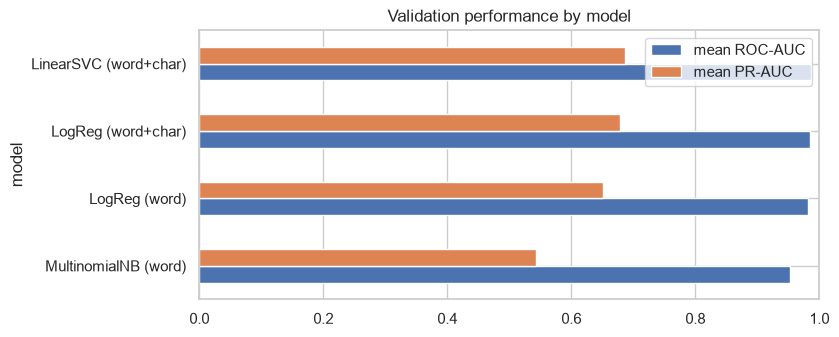

In [12]:
ax = comparison[["mean ROC-AUC", "mean PR-AUC"]].sort_values("mean PR-AUC").plot.barh(figsize=(8, 3.5))
ax.set_xlim(0, 1); ax.set_title("Validation performance by model"); plt.show()

On this run **LinearSVC edged it** on mean validation ROC-AUC (0.9860 vs 0.9854) - a gap well inside
run-to-run noise, and it loses on PR-AUC once thresholds matter. We carry the logistic regression forward
because `predict_proba` gives it calibrated-ish **probabilities**, and the per-label thresholds, the browser
demo and any moderation queue are all built on probabilities. `LinearSVC` only offers a decision margin.

## 8. Per-label threshold tuning
A 0.5 cut-off is a poor default when positives are rare. For each label we pick the threshold that maximises F1
on the validation set (in production you might instead fix a precision target so moderators aren't flooded).

In [13]:
best = fitted["LogReg (word+char)"]
p_va = best.predict_proba(X_va)

thresholds = {}
for i, l in enumerate(LABELS):
    prec, rec, thr = precision_recall_curve(y_va[:, i], p_va[:, i])
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    thresholds[l] = float(thr[np.argmax(f1[:-1])])
pd.Series(thresholds, name="tuned threshold").round(3)

toxic            0.283
severe_toxic     0.065
obscene          0.286
threat           0.135
insult           0.160
identity_hate    0.247
Name: tuned threshold, dtype: float64

## 9. Final evaluation on the official Kaggle test set (real class distribution)

In [14]:
p_te = best.predict_proba(X_te)
thr_vec = np.array([thresholds[l] for l in LABELS])
yhat_te = (p_te >= thr_vec).astype(int)

auc, ap = scores(y_te, p_te)
report = pd.DataFrame({
    "positives in test": y_te.sum(0),
    "ROC-AUC": auc, "PR-AUC": ap,
    "precision": [precision_score(y_te[:, i], yhat_te[:, i], zero_division=0) for i in range(6)],
    "recall":    [recall_score(y_te[:, i], yhat_te[:, i], zero_division=0) for i in range(6)],
    "F1":        [f1_score(y_te[:, i], yhat_te[:, i], zero_division=0) for i in range(6)],
}, index=LABELS)
report.loc["mean"] = report.mean(numeric_only=True)
report.loc["mean", "positives in test"] = np.nan
print(f"Mean column-wise ROC-AUC (Kaggle metric): {auc.mean():.4f}")
print(f"Micro-F1: {f1_score(y_te, yhat_te, average='micro'):.4f} | Macro-F1: {f1_score(y_te, yhat_te, average='macro'):.4f}")
report.round(3)

Mean column-wise ROC-AUC (Kaggle metric): 0.9794
Micro-F1: 0.6366 | Macro-F1: 0.5607


,positives in test,ROC-AUC,PR-AUC,precision,recall,F1
toxic,6090.0,0.965,0.784,0.531,0.870,0.659
severe_toxic,367.0,0.983,0.307,0.178,0.804,0.291
obscene,3691.0,0.978,0.798,0.647,0.763,0.700
threat,211.0,0.993,0.514,0.482,0.583,0.528
insult,3427.0,0.971,0.732,0.535,0.783,0.636
identity_hate,712.0,0.986,0.575,0.561,0.538,0.549
mean,NaN,0.979,0.618,0.489,0.723,0.561


### Why v1's numbers looked better than they were
v1 measured F1 on test splits that were artificially balanced (e.g. 50% toxic). Below we score the **same model**
two ways for each label: on a balanced resample of the test set vs. the real distribution.
Precision — and therefore F1 — typically drops once positives are rare, which is what a real platform sees.

In [15]:
rng = np.random.default_rng(SEED)
rows = []
for i, l in enumerate(LABELS):
    pos = np.where(y_te[:, i] == 1)[0]; neg = np.where(y_te[:, i] == 0)[0]
    bal = np.concatenate([pos, rng.choice(neg, size=len(pos), replace=False)])
    rows.append({"label": l,
                 "F1 on balanced sample (v1-style)": f1_score(y_te[bal, i], yhat_te[bal, i]),
                 "F1 on real distribution": f1_score(y_te[:, i], yhat_te[:, i])})
pd.DataFrame(rows).set_index("label").round(3)

,F1 on balanced sample (v1-style),F1 on real distribution
label,,
toxic,0.891,0.659
severe_toxic,0.887,0.291
obscene,0.854,0.700
threat,0.732,0.528
insult,0.860,0.636
identity_hate,0.698,0.549


## 10. Explainability — which n-grams drive each label?

In [16]:
feat_names = np.concatenate([word_vec.get_feature_names_out(),
                             ["[c]" + f for f in char_vec.get_feature_names_out()]])
top = {}
for l, est in zip(LABELS, best.estimators_):
    coefs = est.coef_.ravel()
    words_only = coefs[: len(word_vec.vocabulary_)]
    top[l] = feat_names[np.argsort(words_only)[::-1][:12]]
pd.DataFrame(top)   # warning: profanity

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,ass,f,ass,die,ass,jew
1,shit,ass in,fuck,kill,you,gay
2,fuck,fuck,shit,i will,idiot,nig
3,crap,you ass,cunt,kill you,moron,nazi
4,hell,you you,bitch,death,asshole,rat
5,idiot,and stop,f,you die,stupid,negro
6,stupid,butt,dick,death to,suck,homo
7,penis,sex,bullshit,burn,fat,is a
8,dick,nigger you,suck,dead,bitch,you
9,fucking,wut,crap,will,scum,nigger


## 11. Error analysis

In [17]:
i = LABELS.index("toxic")
err = test.assign(p=p_te[:, i], y=y_te[:, i])
fp = err[(err.y == 0)].nlargest(5, "p")[["comment_text", "p"]]
fn = err[(err.y == 1)].nsmallest(5, "p")[["comment_text", "p"]]
pd.set_option("display.max_colwidth", 160)
print("Highest-scoring NON-toxic comments (false positives):"); display(fp)
print("Lowest-scoring TOXIC comments (false negatives):");      display(fn)

Highest-scoring NON-toxic comments (false positives):


,comment_text,p
28380,fuck u ill do whatever I fucking want boy,1.000000
56000,== Edit request on 14 January 2013 == \n\n \n\n \n\n \n Cheef keef is a bitch ass dude. He is not about that life and hes a hoe ass dude. He didnt kill...,1.000000
10253,"Who wad the ledaer who said to do it who fucking dumbass, Yellow tooth, horse face3 brit? Clearly if you have any fucking brains, it was Osama Bin Laden who...",1.000000
43308,i dont giv a fuck nick,0.999997
61262,""" \n\n ==Suggestions== \n\n ([A-Za-z])\1{4,};;-1;;v \n\n ([A-Z]){5,};;-1;;v \n\n nig+(er|a)[sz]?;;-1;;v \n\n (h[aoe])\1{3,};;-1;;v \n\n l(o|aw|u)l([zs]...",0.999996


Lowest-scoring TOXIC comments (false negatives):


,comment_text,p
6078,. i was looking for the extra small condom but i couldnt find it so i was looking for a black dildo to work with but not made in asia couse it is to small t...,0.001514
60471,""". I too am sorry for the multiple edits, but I can be rather """"anal"""" about my mistakes""",0.001612
59777,""" \n\n As you can see, I left in the part in which we are SUPPOSED to be discussing here. It was quickly reverted by Shabazz who wrongly claimed that what ...",0.003174
63276,""" \n\n == Your recent bizarre actions == \n\n Have you gone completely nuts? Please undo your recent mass unprotection spree. If you genuinely wish to re-...",0.003789
37783,"""::::The controversy should be covered in the article. Googling frozen gay, there are numerous articles covering it. Wikipedia should summarize the controve...",0.004831


Typical patterns: false positives often **quote** or **discuss** offensive words (e.g. reporting abuse), and false
negatives are toxic **without** profanity (sarcasm, veiled threats) — the kind of context a transformer handles better.

## 12. Fairness check — identity-term false positives
A known issue with this dataset: comments that merely **mention** an identity group get flagged as toxic.
We compare the false-positive rate on non-toxic comments that contain each identity term against the overall rate.

In [18]:
IDENTITY_TERMS = ["gay", "lesbian", "muslim", "jewish", "christian", "black", "white",
                  "woman", "women", "transgender", "african", "mexican", "indian", "asian"]
nontox = test[y_te[:, i] == 0].copy()
nontox["pred"] = yhat_te[y_te[:, i] == 0, i]
overall_fpr = nontox.pred.mean()

rows = []
for term in IDENTITY_TERMS:
    m = nontox.text.str.contains(rf"\b{term}\b", regex=True)
    if m.sum() >= 20:
        rows.append({"term": term, "n non-toxic": int(m.sum()), "FPR": nontox.pred[m].mean()})
bias = pd.DataFrame(rows).set_index("term").sort_values("FPR", ascending=False)
bias["x overall"] = bias.FPR / overall_fpr
print(f"Overall FPR on non-toxic comments: {overall_fpr:.3%}")
bias.round(3)

Overall FPR on non-toxic comments: 8.090%


,n non-toxic,FPR,x overall
term,,,
gay,250,0.472,5.835
woman,203,0.227,2.801
lesbian,38,0.211,2.602
black,582,0.187,2.315
white,519,0.131,1.620
women,332,0.127,1.564
muslim,122,0.107,1.317
jewish,291,0.096,1.189
asian,76,0.092,1.139


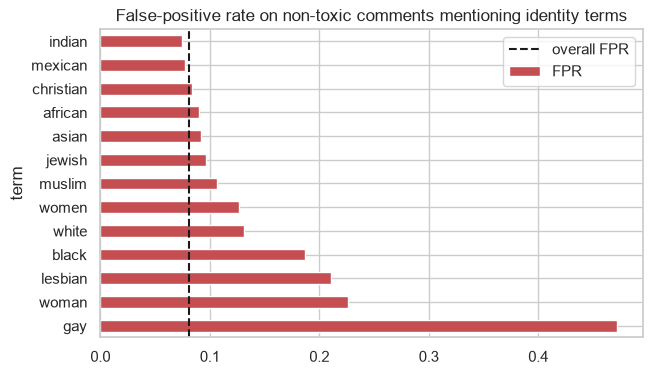

In [19]:
if len(bias):
    ax = bias.FPR.plot.barh(figsize=(7, 4), color="#C44E52")
    ax.axvline(overall_fpr, ls="--", c="k", label="overall FPR"); ax.legend()
    ax.set_title("False-positive rate on non-toxic comments mentioning identity terms"); plt.show()

If some terms show a multiple of the overall FPR, the model has learned the *mention* of the group as a toxicity
signal. Mitigations: data augmentation with neutral identity mentions, per-group threshold review, or training on
Jigsaw's follow-up *Unintended Bias in Toxicity* dataset.

## 13. Package the model
One sklearn `Pipeline` (vectorizers + classifier) plus the tuned thresholds, saved with `joblib`.
Anyone can load it and call `predict_proba` on raw text — no manual preprocessing steps to remember.

In [20]:
features = FeatureUnion([("word", word_vec), ("char", char_vec)])   # already fitted above
# A real TextCleaner, not None: the artifact cleans its own input, so callers pass raw
# comment text. clean_text is idempotent, so passing already-cleaned text is also safe.
pipeline = Pipeline([("clean", TextCleaner()), ("features", features), ("clf", best)])

artifact = {"pipeline": pipeline, "labels": LABELS, "thresholds": thresholds}
os.makedirs("models", exist_ok=True)
joblib.dump(artifact, "models/toxic_tfidf_logreg.joblib", compress=3)
print(f"saved: {os.path.getsize('models/toxic_tfidf_logreg.joblib')/1e6:.1f} MB")

saved: 11.4 MB


In [21]:
def predict_toxicity(texts, artifact=joblib.load("models/toxic_tfidf_logreg.joblib")):
    probs = artifact["pipeline"].predict_proba(texts)        # raw text in - the pipeline cleans it
    out = pd.DataFrame(probs, columns=artifact["labels"]).round(3)
    out.insert(0, "comment", list(texts))
    out["flags"] = [", ".join(l for l in artifact["labels"] if row[l] >= artifact["thresholds"][l]) or "-"
                    for _, row in out.iterrows()]
    return out

predict_toxicity([
    "Thanks for fixing the references, great work!",
    "You are an idiot and nobody wants you here",
    "I will find you and hurt you",
    "What is up garden apple doing",
    "See http://example.com for why 192.168.0.1 is a MORON",   # cleaning matters here
])

,comment,toxic,severe_toxic,obscene,threat,insult,identity_hate,flags
0,"Thanks for fixing the references, great work!",0.000,0.000,0.001,0.000,0.001,0.000,-
1,You are an idiot and nobody wants you here,1.000,0.023,0.398,0.002,0.996,0.024,"toxic, obscene, insult"
2,I will find you and hurt you,0.790,0.006,0.021,0.244,0.029,0.007,"toxic, threat"
3,What is up garden apple doing,0.015,0.002,0.002,0.001,0.003,0.001,-
4,See http://example.com for why 192.168.0.1 is a MORON,0.668,0.004,0.133,0.000,0.273,0.001,"toxic, insult"


## 13b. Export the model for the browser demo
`web/index.html` runs this exact model in the visitor's browser (no server). This cell writes the vocabulary,
IDF weights, coefficients and thresholds to `web/toxic_model_web.json`. Both files deploy together (e.g. on
Vercel), and the page fetches the JSON from alongside itself.

Coefficients are stored as 16-bit integers with a per-label scale, which keeps the file small; the probability
difference versus sklearn is checked below.

In [22]:
import json, base64

def _b64(arr):
    return base64.b64encode(np.ascontiguousarray(arr).tobytes()).decode("ascii")

def export_web_model(path="web/toxic_model_web.json"):
    for v in (word_vec, char_vec):
        assert v.lowercase and v.strip_accents == "unicode" and v.sublinear_tf and v.norm == "l2"
    n_word = len(word_vec.vocabulary_)
    coef = np.vstack([est.coef_.ravel() for est in best.estimators_])          # (6, n_word + n_char)
    intercept = [float(est.intercept_[0]) for est in best.estimators_]
    scale = np.abs(coef).max(axis=1) / 32767.0
    q = np.round(coef / scale[:, None]).astype("<i2")

    model = {
        "version": 1,
        "labels": LABELS,
        "thresholds": [thresholds[l] for l in LABELS],
        "word": {"ngram": list(word_vec.ngram_range), "terms": "\n".join(word_vec.get_feature_names_out()),
                 "idf": _b64(word_vec.idf_.astype("<f4"))},
        "char": {"ngram": list(char_vec.ngram_range), "terms": "\n".join(char_vec.get_feature_names_out()),
                 "idf": _b64(char_vec.idf_.astype("<f4"))},
        "n_word": n_word,
        "coef": {"scale": scale.tolist(), "data": [_b64(row) for row in q]},
        "intercept": intercept,
        "meta": {"train_rows": int(len(train)), "test_rows": int(len(test)),
                 "test_mean_roc_auc": round(float(report.loc["mean", "ROC-AUC"]), 4)},
    }
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with open(path, "w") as f:
        json.dump(model, f, separators=(",", ":"))
    print(f"wrote {path}: {os.path.getsize(path)/1e6:.1f} MB")

    # parity check: dequantised weights vs the real model
    X = hstack([word_vec.transform(X_va_txt[:2000]), char_vec.transform(X_va_txt[:2000])]).tocsr()
    z = X @ (q * scale[:, None]).T + np.array(intercept)
    diff = np.abs(1 / (1 + np.exp(-z)) - best.predict_proba(X)).max()
    print(f"max probability difference after quantisation: {diff:.2e}")
    return path

web_path = export_web_model()

wrote web/toxic_model_web.json: 6.1 MB


max probability difference after quantisation: 6.82e-05


In [23]:
# Download the file from Colab (or copy it to Drive)
try:
    from google.colab import files
    files.download(web_path)
except Exception:
    print("Not in Colab - file is at", web_path)

Not in Colab - file is at web/toxic_model_web.json


## 14. (Optional) Transformer comparison — DistilBERT
Needs a **GPU runtime** in Colab (Runtime → Change runtime type → T4 GPU). Trains on a subset for one epoch
(~15–20 min on a T4) to show how a contextual model compares with the TF-IDF baseline.
Set `RUN_TRANSFORMER = True` to run.

In [24]:
RUN_TRANSFORMER = False
N_TRAIN, N_EVAL, MAX_LEN = 60_000, 20_000, 128

if RUN_TRANSFORMER:
    !pip -q install transformers datasets accelerate
    import torch
    from datasets import Dataset
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer, DataCollatorWithPadding)

    ckpt = "distilbert-base-uncased"
    tok = AutoTokenizer.from_pretrained(ckpt)

    tr_df = train.iloc[tr_idx].sample(N_TRAIN, random_state=SEED)
    te_df = test.sample(min(N_EVAL, len(test)), random_state=SEED)

    def to_ds(df):
        ds = Dataset.from_dict({"text": df.comment_text.tolist(),
                                "labels": df[LABELS].values.astype("float32").tolist()})
        return ds.map(lambda b: tok(b["text"], truncation=True, max_length=MAX_LEN), batched=True)

    ds_tr, ds_te = to_ds(tr_df), to_ds(te_df)
    model = AutoModelForSequenceClassification.from_pretrained(
        ckpt, num_labels=len(LABELS), problem_type="multi_label_classification")

    args = TrainingArguments(output_dir="distilbert-toxic", per_device_train_batch_size=32,
                             per_device_eval_batch_size=64, learning_rate=3e-5, num_train_epochs=1,
                             warmup_ratio=0.06, weight_decay=0.01, fp16=torch.cuda.is_available(),
                             logging_steps=200, save_strategy="no", report_to="none", seed=SEED)
    trainer = Trainer(model=model, args=args, train_dataset=ds_tr,
                      data_collator=DataCollatorWithPadding(tok))
    trainer.train()

    logits = trainer.predict(ds_te).predictions
    p_bert = 1 / (1 + np.exp(-logits))
    y_sub = te_df[LABELS].values
    auc_bert, ap_bert = scores(y_sub, p_bert)
    auc_lr, ap_lr = scores(y_sub, best.predict_proba(hstack([word_vec.transform(te_df.text),
                                                             char_vec.transform(te_df.text)]).tocsr()))
    display(pd.DataFrame({"TF-IDF LogReg AUC": auc_lr, "DistilBERT AUC": auc_bert,
                          "TF-IDF LogReg PR-AUC": ap_lr, "DistilBERT PR-AUC": ap_bert},
                         index=LABELS).round(4))

## 15. Summary
- A single multilabel TF-IDF (word + char) + Logistic Regression model trained on all ~160K comments,
  evaluated honestly on the official Kaggle test set (real class imbalance).
- Reported with the competition metric (mean column-wise ROC-AUC), PR-AUC and F1 at tuned thresholds.
- Showed why balanced-test F1 from v1 overstated performance, explained predictions via top n-grams,
  and audited identity-term false positives.
- Packaged as one `joblib` artifact with a `predict_toxicity()` helper.

**Next steps:** serve the pipeline behind a small FastAPI / Gradio demo; fine-tune a transformer on the full data;
retrain on the Jigsaw *Unintended Bias* dataset to reduce identity-term false positives.